In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_parquet("..\data\data.parquet")

print(df.shape)
df.info(show_counts=True)
df.sample(5)

(24043191, 18)
<class 'pandas.DataFrame'>
RangeIndex: 24043191 entries, 0 to 24043190
Data columns (total 18 columns):
 #   Column                   Non-Null Count     Dtype              
---  ------                   --------------     -----              
 0   observed_at              24043191 non-null  datetime64[us, UTC]
 1   stop_id                  24043191 non-null  str                
 2   stop_name                24043191 non-null  str                
 3   line_id                  24043191 non-null  str                
 4   direction                24043191 non-null  str                
 5   platform_name            24043191 non-null  str                
 6   destination_name         24030718 non-null  str                
 7   hour                     24043191 non-null  int32              
 8   weekday                  24043191 non-null  int32              
 9   is_weekend               24043191 non-null  int64              
 10  time_to_station          24043191 non-null  int6

,observed_at,stop_id,stop_name,line_id,direction,platform_name,destination_name,hour,weekday,is_weekend,time_to_station,roll_mean_tts_10m,roll_max_tts_10m,roll_count_10m,roll_std_tts_10m,baseline_median_tts,deviation_from_baseline,late
8357009,2026-02-26 08:15:19.265287+00:00,940GZZLUHAI,Highbury & Islington Underground Station,victoria,inbound,Southbound - Platform 5,Brixton Underground Station,8,3,0,420,293.256410,666.0,273.0,None,329.0,91.0,0
13210836,2026-02-28 07:39:55.938726+00:00,940GZZLUSJW,St. John's Wood Underground Station,jubilee,inbound,Northbound - Platform 1,Stanmore Underground Station,7,5,1,1112,937.462604,1790.0,361.0,None,983.0,129.0,0
11538371,2026-02-28 16:14:39.544637+00:00,940GZZLUNGW,North Greenwich Underground Station,jubilee,outbound,Eastbound - Platform 3,Stratford Underground Station,16,5,1,1580,934.435950,1841.0,484.0,None,903.0,677.0,1
14373991,2026-02-25 22:14:39.186663+00:00,940GZZLUSTD,Stratford Underground Station,jubilee,unknown,Westbound - Platform 13,Stratford Underground Station,22,2,0,1616,883.937912,1814.0,1063.0,None,879.0,737.0,1
17684552,2026-02-26 11:54:11.045984+00:00,940GZZLUSWK,Southwark Underground Station,jubilee,outbound,Eastbound - Platform 2,Stratford Underground Station,11,3,0,372,777.312500,1672.0,384.0,None,728.0,-356.0,0


In [3]:
df.describe()

,hour,weekday,is_weekend,time_to_station,roll_mean_tts_10m,roll_max_tts_10m,roll_count_10m,baseline_median_tts,deviation_from_baseline,late
count,2.404319e+07,2.404319e+07,2.404319e+07,2.404319e+07,2.404319e+07,2.404319e+07,2.404319e+07,2.404319e+07,2.404319e+07,2.404319e+07
mean,1.357535e+01,2.923082e+00,2.674414e-01,7.442601e+02,7.470698e+02,1.497336e+03,4.623664e+02,7.367591e+02,7.500955e+00,2.756518e-01
std,5.891737e+00,1.919967e+00,4.426246e-01,4.960019e+02,2.205886e+02,4.313433e+02,3.245692e+02,2.177443e+02,4.495845e+02,4.468421e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,-1.721000e+03,0.000000e+00
25%,9.000000e+00,1.000000e+00,0.000000e+00,3.120000e+02,6.335306e+02,1.251000e+03,2.760000e+02,6.280000e+02,-3.340000e+02,0.000000e+00
50%,1.400000e+01,3.000000e+00,0.000000e+00,6.840000e+02,8.203705e+02,1.728000e+03,3.820000e+02,8.050000e+02,0.000000e+00,0.000000e+00
75%,1.800000e+01,5.000000e+00,1.000000e+00,1.128000e+03,8.966459e+02,1.794000e+03,4.940000e+02,8.850000e+02,3.430000e+02,1.000000e+00
max,2.300000e+01,6.000000e+00,1.000000e+00,1.859000e+03,1.851000e+03,1.859000e+03,1.950000e+03,1.840000e+03,1.350000e+03,1.000000e+00


In [4]:
df.isna().sum().sort_values(ascending=False)

roll_std_tts_10m           24043191
destination_name              12473
stop_id                           0
observed_at                       0
direction                         0
stop_name                         0
platform_name                     0
hour                              0
weekday                           0
line_id                           0
is_weekend                        0
time_to_station                   0
roll_max_tts_10m                  0
roll_mean_tts_10m                 0
roll_count_10m                    0
baseline_median_tts               0
deviation_from_baseline           0
late                              0
dtype: int64

destination_name values: 12,473 / 24,043,191

That is 0.05% missing.
This is negligible and probably caused by API responses where destination was not specified.
It does not threaten the dataset quality.

In [5]:
# Time ordering the data by observed_at
'''This is extremely important because later you must do:
time-aware train/test split
Without sorting, the model might accidentally learn from the future.
So this step ensures:
temporal integrity'''

df = df.sort_values("observed_at")

In [6]:
df

,observed_at,stop_id,stop_name,line_id,direction,platform_name,destination_name,hour,weekday,is_weekend,time_to_station,roll_mean_tts_10m,roll_max_tts_10m,roll_count_10m,roll_std_tts_10m,baseline_median_tts,deviation_from_baseline,late
16281153,2026-02-24 20:06:53.740138+00:00,940GZZLUSVS,Seven Sisters Underground Station,victoria,inbound,Southbound - Platform 5,Brixton Underground Station,20,1,0,144,99.000000,144.0,2.0,None,150.0,-6.0,0
17102488,2026-02-24 20:06:53.740138+00:00,940GZZLUSWC,Swiss Cottage Underground Station,jubilee,outbound,Southbound - Platform 2,Stratford Underground Station,20,1,0,351,545.666667,1070.0,6.0,None,835.0,-484.0,0
2034947,2026-02-24 20:06:53.740138+00:00,940GZZLUBST,Baker Street Underground Station,jubilee,outbound,Southbound - Platform 7,Stratford Underground Station,20,1,0,768,810.857143,1428.0,7.0,None,887.0,-119.0,0
2034946,2026-02-24 20:06:53.740138+00:00,940GZZLUBST,Baker Street Underground Station,jubilee,outbound,Southbound - Platform 7,Stratford Underground Station,20,1,0,588,818.000000,1428.0,6.0,None,887.0,-299.0,0
2034945,2026-02-24 20:06:53.740138+00:00,940GZZLUBST,Baker Street Underground Station,jubilee,outbound,Southbound - Platform 7,Stratford Underground Station,20,1,0,1248,864.000000,1428.0,5.0,None,887.0,361.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6587246,2026-03-04 19:31:42.221417+00:00,940GZZLUFPK,Finsbury Park Underground Station,victoria,outbound,Northbound - Platform 2,Walthamstow Central Underground Station,19,2,0,634,582.523457,1189.0,405.0,None,525.0,109.0,0
6587247,2026-03-04 19:31:42.221417+00:00,940GZZLUFPK,Finsbury Park Underground Station,victoria,outbound,Northbound - Platform 2,Walthamstow Central Underground Station,19,2,0,93,581.317734,1189.0,406.0,None,525.0,-432.0,0
6587248,2026-03-04 19:31:42.221417+00:00,940GZZLUFPK,Finsbury Park Underground Station,victoria,outbound,Northbound - Platform 2,Walthamstow Central Underground Station,19,2,0,514,581.152334,1189.0,407.0,None,525.0,-11.0,0
6587250,2026-03-04 19:31:42.221417+00:00,940GZZLUFPK,Finsbury Park Underground Station,victoria,outbound,Northbound - Platform 2,Walthamstow Central Underground Station,19,2,0,393,581.555012,1189.0,409.0,None,525.0,-132.0,0


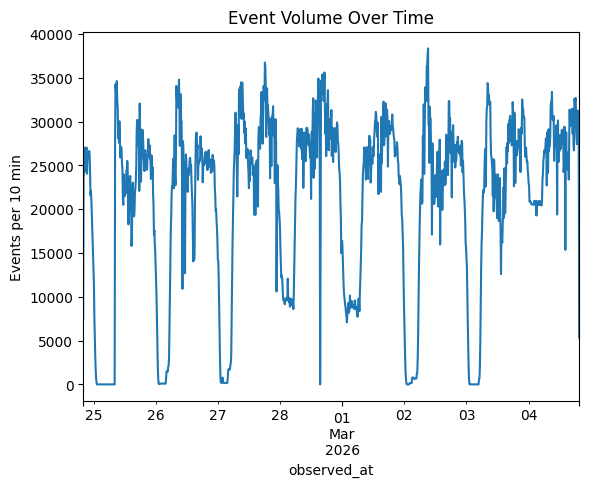

In [7]:
import matplotlib.pyplot as plt

df.set_index("observed_at").resample("10min").size().plot()
plt.title("Event Volume Over Time")
plt.ylabel("Events per 10 min")
plt.show()

----------------------------------------------------------------------------------------------------------------------------------------------------------------

# Health check for the data pipeline.

In [8]:
counts_10m = df.set_index("observed_at").resample("10min").size()

threshold = 100
low_bins = counts_10m < threshold

gap_percentage = low_bins.mean() * 100
total_gap_minutes = low_bins.sum() * 10

print("Gap percentage:", gap_percentage)
print("Total gap minutes:", total_gap_minutes)

Gap percentage: 7.82608695652174
Total gap minutes: 900


In [9]:
s = low_bins.astype(int)
grp = (s != s.shift()).cumsum()

intervals = (
    counts_10m[low_bins]
    .to_frame("events")
    .assign(group=grp[low_bins].values)
    .groupby("group")
    .agg(start=("events", lambda x: x.index.min()),
         end=("events", lambda x: x.index.max()),
         bins=("events", "size"))
)

intervals["minutes"] = intervals["bins"] * 10

longest_gap = intervals["minutes"].max()

print("Longest gap (minutes):", longest_gap)

Longest gap (minutes): 420


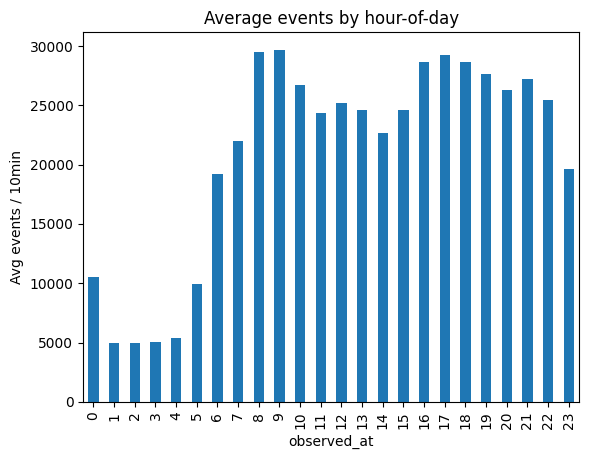

In [10]:
hourly_profile = counts_10m.groupby(counts_10m.index.hour).mean()
hourly_profile.plot(kind="bar", title="Average events by hour-of-day")
plt.ylabel("Avg events / 10min")
plt.show()


In [11]:
# Pick threshold: either hard threshold or percentile-based
thr = max(10, counts_10m.quantile(0.01))  # adjust as needed
low_bins = counts_10m <= thr

gap_minutes = int(low_bins.sum() * 10)
gap_pct = low_bins.mean() * 100

print(f"Threshold: <= {thr:.1f} events/10min")
print(f"Low-volume bins: {low_bins.sum()} / {len(counts_10m)}")
print(f"Gap minutes: {gap_minutes}")
print(f"Gap percent: {gap_pct:.2f}%")


Threshold: <= 10.0 events/10min
Low-volume bins: 71 / 1150
Gap minutes: 710
Gap percent: 6.17%


In [12]:
s = low_bins.astype(int)
grp = (s != s.shift()).cumsum()

intervals = (
    counts_10m[low_bins]
    .to_frame(name="events")
    .assign(group=grp[low_bins].values)
    .groupby("group")
    .agg(
        start=("events", lambda x: x.index.min()),
        end=("events", lambda x: x.index.max()),
        bins=("events", "size"),
    )
)

intervals["minutes"] = intervals["bins"] * 10
intervals = intervals.sort_values(by="minutes", ascending=False).reset_index(drop=True)

intervals.head(20)


,start,end,bins,minutes
0,2026-02-25 01:20:00+00:00,2026-02-25 08:10:00+00:00,42,420
1,2026-03-03 01:10:00+00:00,2026-03-03 04:40:00+00:00,22,220
2,2026-03-02 01:00:00+00:00,2026-03-02 01:50:00+00:00,6,60
3,2026-02-28 15:30:00+00:00,2026-02-28 15:30:00+00:00,1,10


In [13]:
# strict outage only
zero_bins = counts_10m == 0

# near-outage
low1_bins = counts_10m <= 1
low10_bins = counts_10m <= 10

def summarize(mask, name):
    s = mask.astype(int)
    grp = (s != s.shift()).cumsum()
    ints = (
        counts_10m[mask].to_frame("events")
        .assign(group=grp[mask].values)
        .groupby("group")
        .agg(start=("events", lambda x: x.index.min()),
             end=("events", lambda x: x.index.max()),
             bins=("events","size"))
    )
    if len(ints) == 0:
        print(name, "no intervals")
        return
    ints["minutes"] = ints["bins"] * 10
    print(f"\n{name}: total_gap_min={ints['minutes'].sum()}, longest_min={ints['minutes'].max()}")
    print(ints.sort_values("minutes", ascending=False).head(5))

summarize(zero_bins, "==0")
summarize(low1_bins, "<=1")
summarize(low10_bins, "<=10")



==0: total_gap_min=690, longest_min=420
                          start                       end  bins  minutes
group                                                                   
2     2026-02-25 01:20:00+00:00 2026-02-25 08:10:00+00:00    42      420
8     2026-03-03 01:20:00+00:00 2026-03-03 04:30:00+00:00    20      200
6     2026-03-02 01:00:00+00:00 2026-03-02 01:50:00+00:00     6       60
4     2026-02-28 15:30:00+00:00 2026-02-28 15:30:00+00:00     1       10

<=1: total_gap_min=700, longest_min=420
                          start                       end  bins  minutes
group                                                                   
2     2026-02-25 01:20:00+00:00 2026-02-25 08:10:00+00:00    42      420
8     2026-03-03 01:20:00+00:00 2026-03-03 04:40:00+00:00    21      210
6     2026-03-02 01:00:00+00:00 2026-03-02 01:50:00+00:00     6       60
4     2026-02-28 15:30:00+00:00 2026-02-28 15:30:00+00:00     1       10

<=10: total_gap_min=710, longest_min=420


<Axes: xlabel='observed_at'>

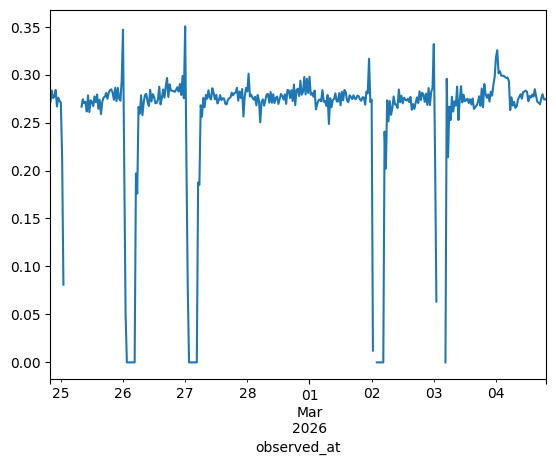

In [14]:
late_rate = (
    df.set_index("observed_at")
      .resample("30min")["late"]
      .mean()
)

late_rate.plot()

## Data Collection Gaps and Dataset Integrity

### Motivation

During exploratory data analysis of the 8-day real-time dataset, the event volume over time revealed several sharp drops to near-zero counts. These appeared as deep troughs in the resampled time series when visualizing the number of events per 10-minute window.

At first glance, these dips could suggest problems with the dataset, such as missing observations or data corruption. Therefore, a systematic audit of the data collection process was performed.

---

### Gap Detection Procedure

To investigate potential collection interruptions, the dataset was resampled into 10-minute windows and intervals with extremely low event counts were identified.

The following low-volume intervals were detected:

| start | end | minutes |
|---|---|---|
| 2026-02-25 01:20 | 2026-02-25 08:10 | 420 |
| 2026-03-03 01:10 | 2026-03-03 04:40 | 220 |
| 2026-03-02 01:00 | 2026-03-02 01:50 | 60 |
| 2026-02-28 15:30 | 2026-02-28 15:30 | 10 |

The total missing time coverage corresponds to approximately **900 minutes**, or **~7.8% of the total 8-day collection period**.

The largest gap (420 minutes) corresponds to a confirmed system interruption caused by a Windows update and collector restart.

---

### Important Distinction: Event Streams vs Regular Time Series

This dataset represents an **event stream**, where each row corresponds to a real-time arrival prediction event from the TfL API.

In event streams:

- events occur irregularly
- timestamps represent when events occur
- missing time windows naturally contain **no rows**

Therefore, the identified gaps do **not correspond to corrupted rows**. Instead, they represent **periods where the collector was temporarily not running**, and therefore no events were recorded.

This means that the dataset contains **valid event records**, but does not provide continuous coverage for every minute of the 8-day period.

---

### Impact on Modeling

The machine learning models in this project operate on **individual event records**, not on regularly sampled time intervals.

Because the missing intervals contain **no rows rather than invalid rows**, they do not introduce incorrect feature values or label noise into the dataset.

Additionally:

- timestamps remain monotonic
- no duplicate rows are present
- feature engineering based on actual timestamps remains valid

For these reasons, no row-level cleaning or removal was necessary.

---

### Final Decision

The dataset is kept **unchanged** for further analysis and modeling.

The identified gaps are documented as **collector outages**, but they do not compromise the integrity of the event-level data used for machine learning.

---

### Dataset Integrity Verification

Two additional checks confirm structural integrity of the dataset:

- timestamps are strictly ordered
- no duplicate rows exist

This confirms that the dataset is consistent and suitable for further analysis.

In [15]:
# Detected outage intervals from the gap audit
gap_intervals = [
    ("2026-02-25 01:20:00+00:00", "2026-02-25 08:10:00+00:00"),
    ("2026-03-03 01:10:00+00:00", "2026-03-03 04:40:00+00:00"),
    ("2026-03-02 01:00:00+00:00", "2026-03-02 01:50:00+00:00"),
    ("2026-02-28 15:30:00+00:00", "2026-02-28 15:30:00+00:00"),
]

# Start with keeping all rows
mask_keep = pd.Series(True, index=df.index)

# Exclude rows whose timestamps fall inside any detected outage interval
for start, end in gap_intervals:
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)
    mask_keep &= ~df["observed_at"].between(start, end)

# Create cleaned dataframe
df_clean = df.loc[mask_keep].copy()

# Show summary
rows_removed = len(df) - len(df_clean)
pct_removed = rows_removed / len(df) * 100

print(f"Original dataframe shape : {df.shape}")
print(f"Cleaned dataframe shape  : {df_clean.shape}")
print(f"Rows removed             : {rows_removed:,}")
print(f"Percent rows removed     : {pct_removed:.4f}%")

Original dataframe shape : (24043191, 18)
Cleaned dataframe shape  : (24043182, 18)
Rows removed             : 9
Percent rows removed     : 0.0000%


In [16]:
df_clean.to_parquet("data_cleaned_gaps_removed.parquet", index=False)
print("Saved cleaned dataset to: data_cleaned_gaps_removed.parquet")

Saved cleaned dataset to: data_cleaned_gaps_removed.parquet


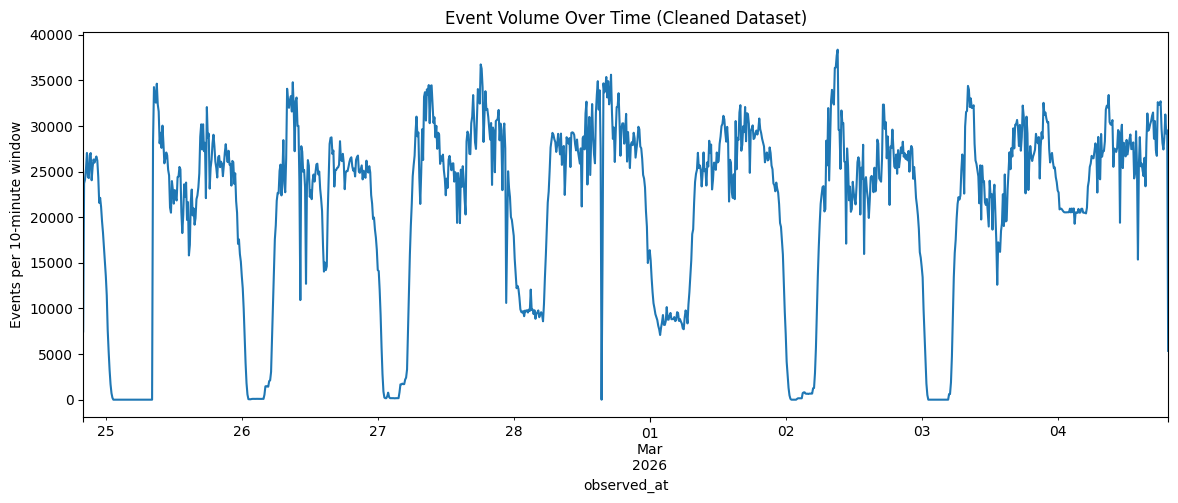

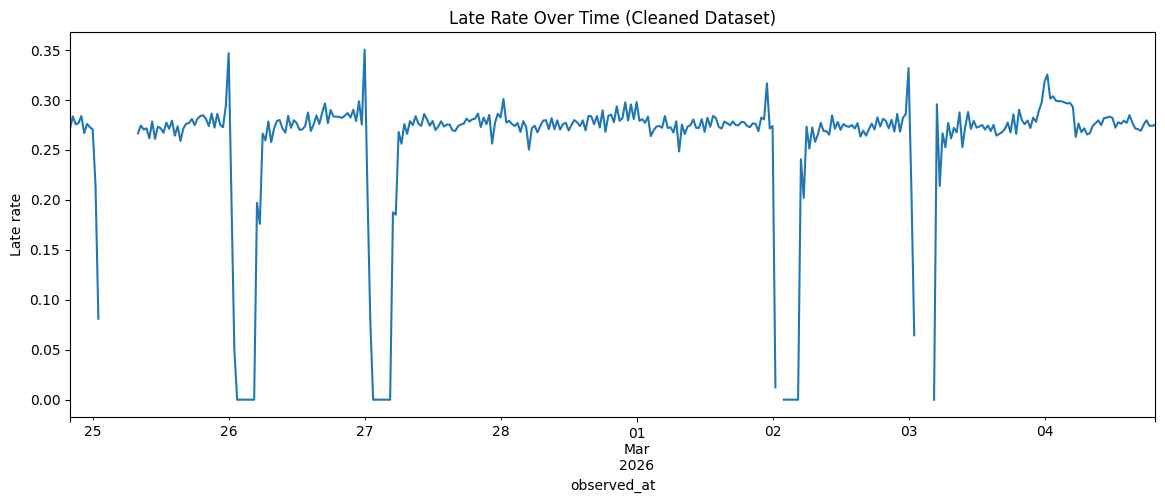

In [17]:
import matplotlib.pyplot as plt

# Event volume over time after removing outage intervals
counts_10m_clean = (
    df_clean.set_index("observed_at")
    .resample("10min")
    .size()
)

plt.figure(figsize=(14, 5))
counts_10m_clean.plot()
plt.title("Event Volume Over Time (Cleaned Dataset)")
plt.xlabel("observed_at")
plt.ylabel("Events per 10-minute window")
plt.show()

# Late rate over time after cleaning
late_rate_clean = (
    df_clean.set_index("observed_at")
    .resample("30min")["late"]
    .mean()
)

plt.figure(figsize=(14, 5))
late_rate_clean.plot()
plt.title("Late Rate Over Time (Cleaned Dataset)")
plt.xlabel("observed_at")
plt.ylabel("Late rate")
plt.show()

In [18]:
df["observed_at"].is_monotonic_increasing
df.duplicated().sum()

np.int64(0)

-------------------------------------------------------------------------------------------------------------------------------------------------------------------

late
0    0.724348
1    0.275652
Name: proportion, dtype: float64


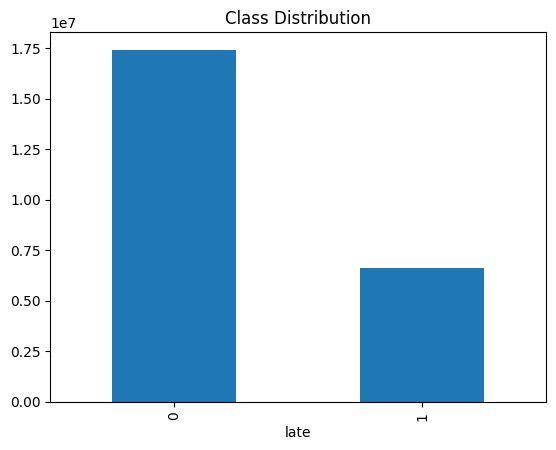

In [19]:
print(df["late"].value_counts(normalize=True))

df["late"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.show()

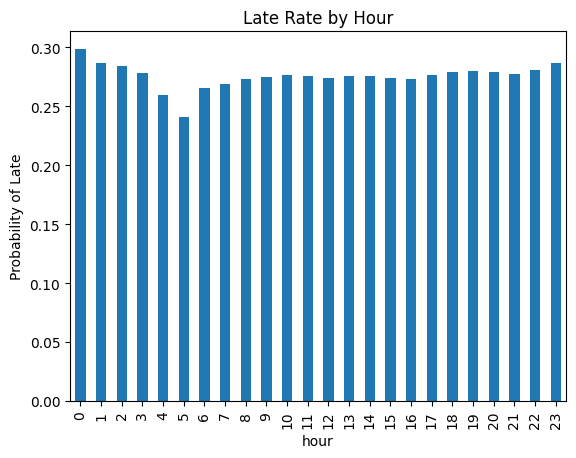

In [20]:
late_by_hour = df.groupby("hour")["late"].mean()

late_by_hour.plot(kind="bar")
plt.title("Late Rate by Hour")
plt.ylabel("Probability of Late")
plt.show()

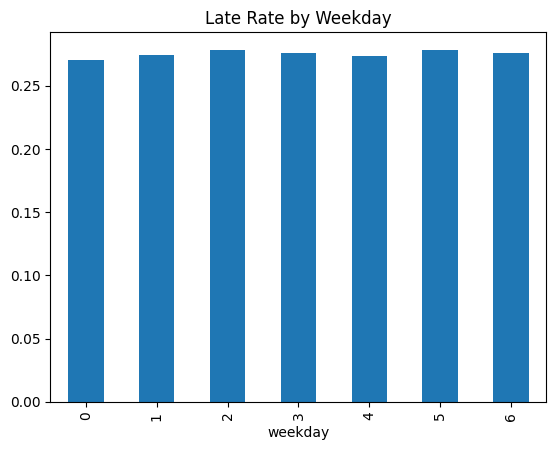

In [21]:
late_by_weekday = df.groupby("weekday")["late"].mean()

late_by_weekday.plot(kind="bar")
plt.title("Late Rate by Weekday")
plt.show()

In [22]:
station_late = (
    df.groupby("stop_name")["late"]
    .mean()
    .sort_values(ascending=False)
)

station_late.head(20)

stop_name
Baker Street Underground Station           0.347440
Bond Street Underground Station            0.339722
St. John's Wood Underground Station        0.333753
Stratford Underground Station              0.333541
Swiss Cottage Underground Station          0.326474
Finchley Road Underground Station          0.317127
Walthamstow Central Underground Station    0.315780
Neasden Underground Station                0.305976
Blackhorse Road Underground Station        0.305583
Kilburn Underground Station                0.302885
West Hampstead Underground Station         0.302376
Stanmore Underground Station               0.301879
West Ham Underground Station               0.294726
Westminster Underground Station            0.294369
Canning Town Underground Station           0.290694
Waterloo Underground Station               0.286787
Tottenham Hale Underground Station         0.282520
Queensbury Underground Station             0.282477
Canons Park Underground Station            0.282386
Do

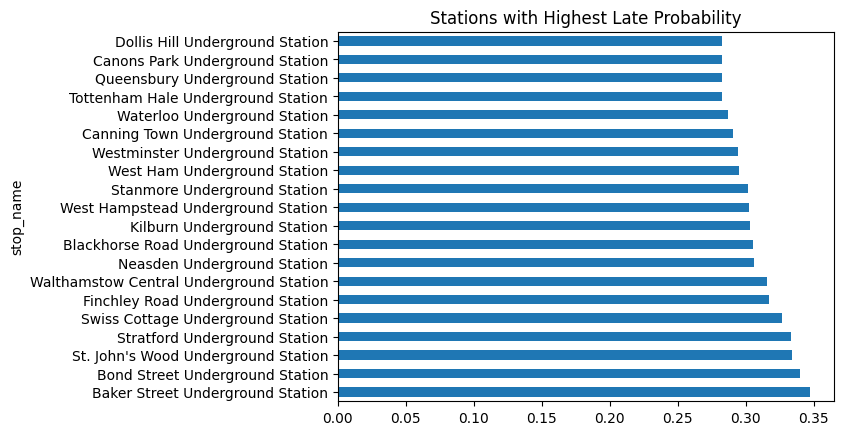

In [23]:
station_late.head(20).plot(kind="barh")
plt.title("Stations with Highest Late Probability")
plt.show()

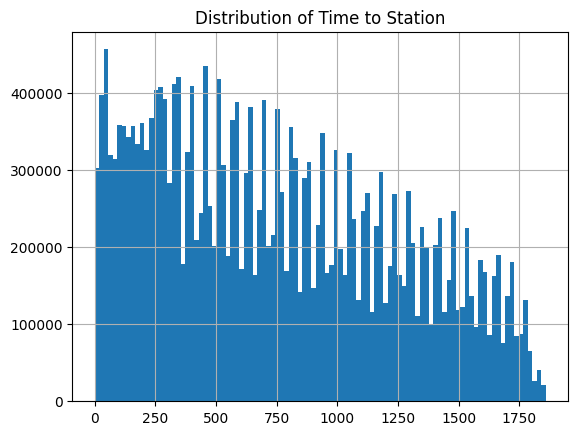

In [24]:
df["time_to_station"].hist(bins=100)
plt.title("Distribution of Time to Station")
plt.show()

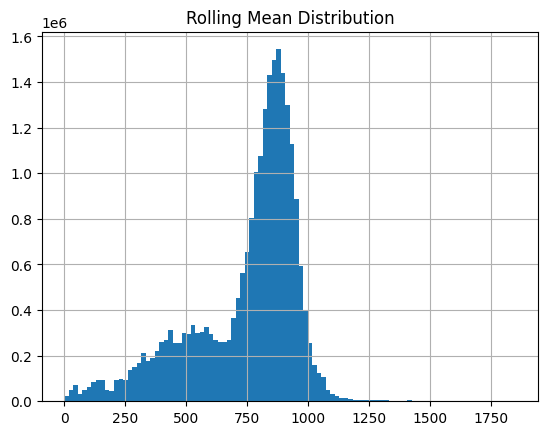

In [25]:
df["roll_mean_tts_10m"].hist(bins=100)
plt.title("Rolling Mean Distribution")
plt.show()

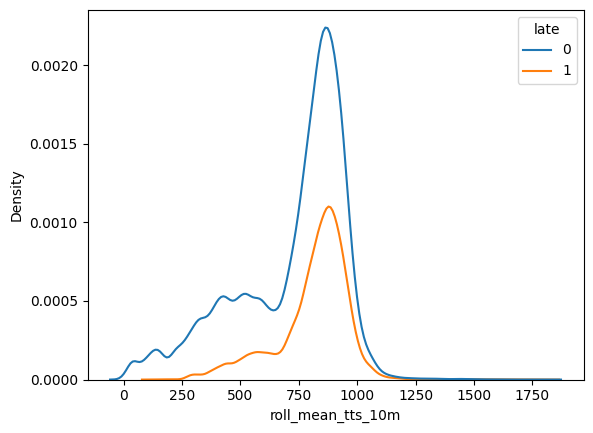

In [26]:
# Compare Feature Distributions by Class
sns.kdeplot(data=df.sample(200000), x="roll_mean_tts_10m", hue="late")
plt.show()

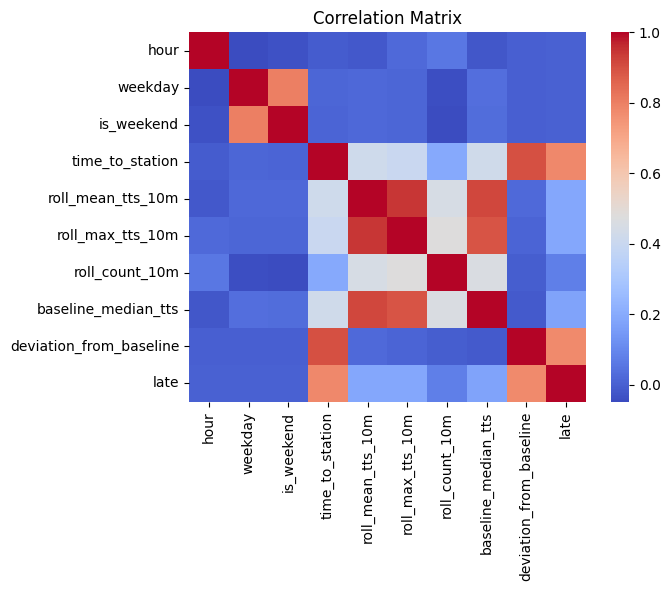

In [27]:
# Correlation Matrix
sample_df = df.sample(200000)

corr = sample_df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

stop_id
940GZZLUCGT    549.591820
940GZZLUKBY    542.448493
940GZZLUQBY    540.419750
940GZZLUNGW    538.867974
940GZZLUWYP    534.876686
940GZZLUWHM    532.189306
940GZZLUNDN    531.045032
940GZZLUBXN    527.928020
940GZZLUCYF    524.098508
940GZZLUCPK    521.610916
940GZZLUWWL    520.432501
940GZZLUSTD    519.045255
940GZZLUSKW    518.585962
940GZZLUBST    516.776479
940GZZLUSJW    513.977322
940GZZLUSTM    509.600652
940GZZLUFYR    507.775623
940GZZLUBLR    506.982274
940GZZLUDOH    506.798505
940GZZLUSWC    504.596203
940GZZLUWIG    499.446617
940GZZLUWHP    495.590385
940GZZLUBND    491.563370
940GZZLUCWR    491.358335
940GZZLUVXL    487.221380
940GZZLUKBN    487.119218
940GZZLULNB    482.018502
940GZZLUTMH    481.503318
940GZZLUBMY    477.589207
940GZZLUWSM    466.346349
940GZZLUPCO    460.705622
940GZZLUSWK    453.799729
940GZZLUWLO    453.499357
940GZZLUSVS    436.561914
940GZZLUGPK    431.872650
940GZZLUVIC    401.010164
940GZZLUFPK    341.594152
940GZZLUHAI    298.456734
940G

Text(0.5, 1.0, 'Top 20 Noisy Stations')

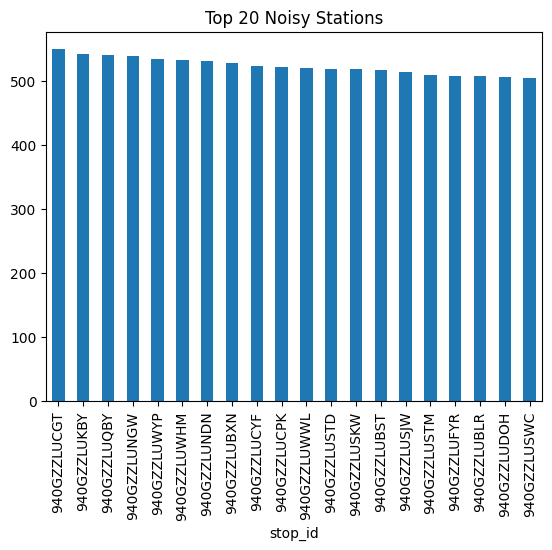

In [28]:
# Check Prediction Noise
print(df.groupby("stop_id")["time_to_station"].std().sort_values(ascending=False))
# plot prediction noise for top 20 noisy stations
df.groupby("stop_id")["time_to_station"].std().sort_values(ascending=False).head(20).plot(kind="bar")
plt.title("Top 20 Noisy Stations")

In [29]:
df.nunique()

observed_at                   47997
stop_id                          42
stop_name                        42
line_id                           2
direction                         3
platform_name                    26
destination_name                  9
hour                             24
weekday                           7
is_weekend                        2
time_to_station                1859
roll_mean_tts_10m          17900789
roll_max_tts_10m               1858
roll_count_10m                 1950
roll_std_tts_10m                  0
baseline_median_tts            1986
deviation_from_baseline        4905
late                              2
dtype: int64

# Station Dominance / Sampling Bias

Now we analyze something much more important than gaps.

In transit data, some stations may produce far more events than others. If one station dominates the dataset, the ML model can become biased.

We will check:

- event count per station
- percentage contribution per station
- late-rate per station

Interpretation:

- if top station > 20% → severe imbalance

- if top station ~5–10% → moderate

- if top station <5% → healthy

In [30]:
station_counts = df["stop_name"].value_counts()

station_counts.head(20)

stop_name
Stratford Underground Station              1134967
Green Park Underground Station             1112740
Brixton Underground Station                 970294
Walthamstow Central Underground Station     931092
Stanmore Underground Station                920525
Baker Street Underground Station            682995
St. John's Wood Underground Station         664977
Bond Street Underground Station             657740
Swiss Cottage Underground Station           640927
Finchley Road Underground Station           630656
Westminster Underground Station             619886
West Hampstead Underground Station          603283
Waterloo Underground Station                592071
Southwark Underground Station               585168
London Bridge Underground Station           581781
Kilburn Underground Station                 571946
Willesden Green Underground Station         559089
Bermondsey Underground Station              552084
Canada Water Underground Station            531287
Canary Wharf Undergro

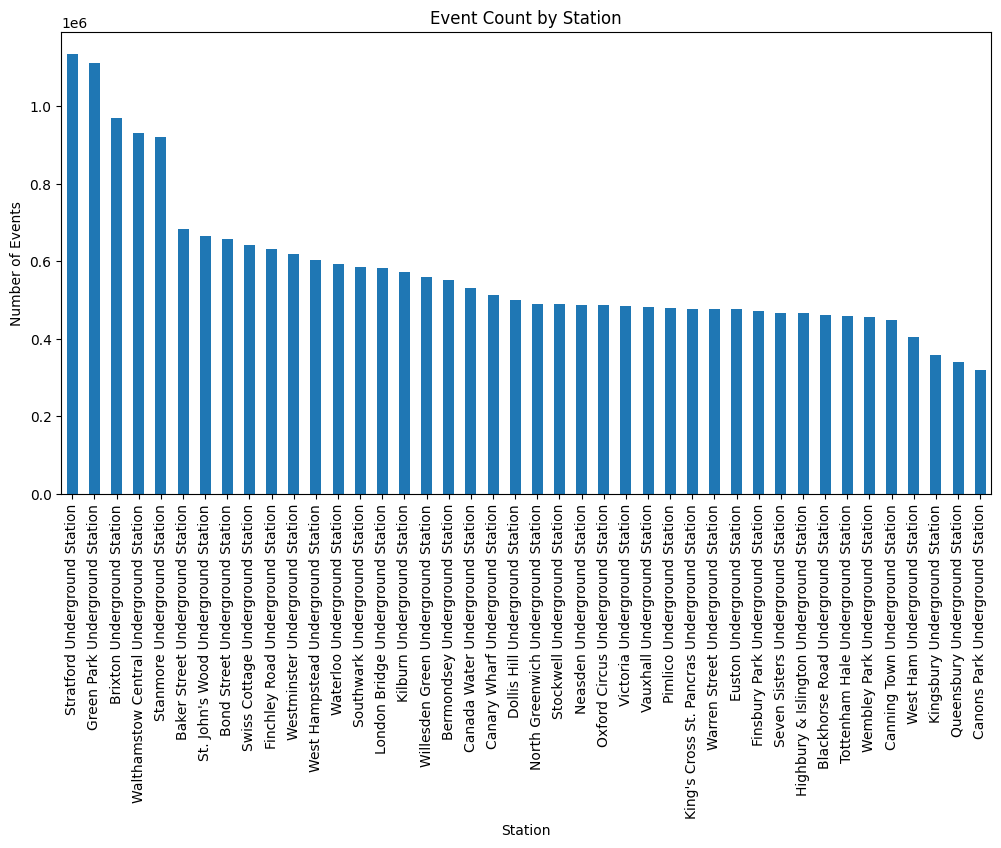

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
station_counts.plot(kind="bar")
plt.title("Event Count by Station")
plt.ylabel("Number of Events")
plt.xlabel("Station")
plt.show()

In [32]:
station_share = (station_counts / len(df)) * 100

station_share.sort_values(ascending=False).head(10)

stop_name
Stratford Underground Station              4.720534
Green Park Underground Station             4.628088
Brixton Underground Station                4.035629
Walthamstow Central Underground Station    3.872581
Stanmore Underground Station               3.828631
Baker Street Underground Station           2.840700
St. John's Wood Underground Station        2.765760
Bond Street Underground Station            2.735660
Swiss Cottage Underground Station          2.665732
Finchley Road Underground Station          2.623013
Name: count, dtype: float64

In [33]:
station_late_rate = df.groupby("stop_name")["late"].mean().sort_values(ascending=False)

station_late_rate.head(20)

stop_name
Baker Street Underground Station           0.347440
Bond Street Underground Station            0.339722
St. John's Wood Underground Station        0.333753
Stratford Underground Station              0.333541
Swiss Cottage Underground Station          0.326474
Finchley Road Underground Station          0.317127
Walthamstow Central Underground Station    0.315780
Neasden Underground Station                0.305976
Blackhorse Road Underground Station        0.305583
Kilburn Underground Station                0.302885
West Hampstead Underground Station         0.302376
Stanmore Underground Station               0.301879
West Ham Underground Station               0.294726
Westminster Underground Station            0.294369
Canning Town Underground Station           0.290694
Waterloo Underground Station               0.286787
Tottenham Hale Underground Station         0.282520
Queensbury Underground Station             0.282477
Canons Park Underground Station            0.282386
Do

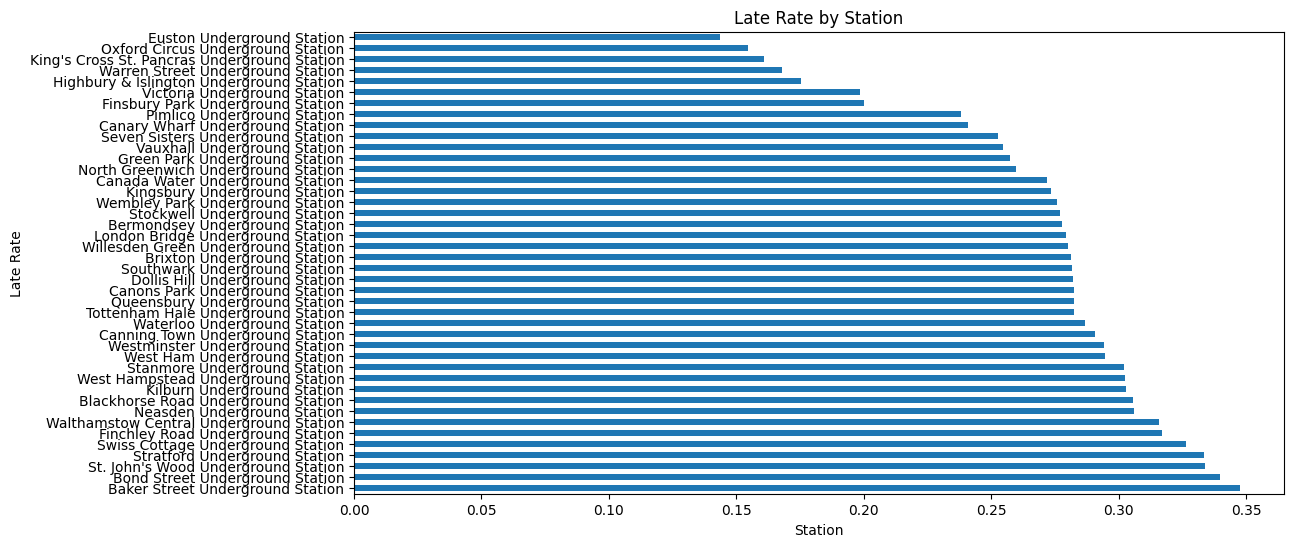

In [34]:
plt.figure(figsize=(12,6))
station_late_rate.plot(kind="barh")
plt.title("Late Rate by Station")
plt.ylabel("Late Rate")
plt.xlabel("Station")
plt.show()

In [35]:
df.columns

Index(['observed_at', 'stop_id', 'stop_name', 'line_id', 'direction',
       'platform_name', 'destination_name', 'hour', 'weekday', 'is_weekend',
       'time_to_station', 'roll_mean_tts_10m', 'roll_max_tts_10m',
       'roll_count_10m', 'roll_std_tts_10m', 'baseline_median_tts',
       'deviation_from_baseline', 'late'],
      dtype='str')

In [36]:
df.drop(columns=[ 'deviation_from_baseline'], inplace=True)

# Target Leakage
Target leakage happens when a feature contains information that directly determines the target variable.

Definition:
Target leakage occurs when the model has access to information that would not be available at prediction time or directly reveals the label.
In our case:
deviation_from_baseline → defines late

So it is perfect leakage and hence it is best to drop ''deviation_from_baseline'' column!

**What happens if we keep deviation_from_baseline as a feature**

Imagine we train a model with this feature included.

- The model sees:

Input feature: deviation_from_baseline
Target: late

- But the target is defined as:

late = deviation_from_baseline ≥ threshold

- So the model can easily learn the rule:

if deviation_from_baseline > threshold → late = 1

`This means the model is essentially being given the answer.`

**We want the model to infer delay risk from the environment, not from the label formula.**

`Meaning the model should learn patterns such as:`

- rolling delay increasing
- station historically problematic
- train far from station
- time of day effects

Those are real signals.

So we keep features like:

- time_to_station
- roll_mean_tts_10m
- roll_max_tts_10m
- baseline_median_tts
- hour
- weekday
- station

But we remove the feature that directly computes the label.

`Did any feature help construct the label? ------->   If yes:  remove it from the model`

In [37]:
df["roll_std_tts_10m"].isna().sum()

np.int64(24043191)

In [38]:
df.drop(columns=[ 'roll_std_tts_10m'], inplace=True)

In [39]:
df.shape

(24043191, 16)

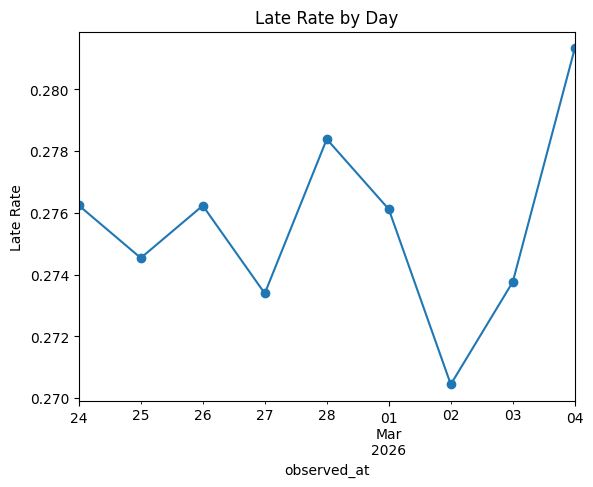

In [40]:
late_by_day = (
    df.set_index("observed_at")
      .resample("1D")["late"]
      .mean()
)

late_by_day

late_by_day.plot(marker="o")
plt.title("Late Rate by Day")
plt.ylabel("Late Rate")
plt.show()